# Demo part 2: Using the ML modeling API

In this notebook, we will illustrate how to train an XGBoost model with the diabetes dataset using the Snowpark ML Model API. 
- The goal of the notebook is to show the Machine Learning capabilities of Snowflake, not to create a model that predicts well
- We also show how to do inference and deploy the model as a UDF.


<a id="topics"></a>
### Topics in this Lesson


1. [Load the data & preprocessing pipeline](#Load_the_data)  
    1. [Load the Pickled Pipeline](#Pickled_Pipeline)   
    1. [Split the data into a test and train df](#data_split)
1. [Build a simple XGBoost Regression model](#XGBoost)  
    1. [Fit the regressor](#regressor_fit)  
    1. [Notice that we need to refer to column names?](#notice)  
    1. [Calculate the MAPE](#MAPE) 
    1. [Deploy the simple model as a UDF](#deploy_udf) 
    1. [Gridsearch](#Gridsearch)      

#### Install if still needed:

In [2]:
#pip install snowflake-ml-python

In [3]:
#pip install fastparquet==2023.8.0

### Import Libraries

In [4]:
# Snowpark for Python
from snowflake.snowpark import Session
from snowflake.snowpark.version import VERSION
from snowflake.snowpark.functions import udf
import snowflake.snowpark.functions as F

# Snowpark ML
import snowflake.ml.modeling.preprocessing as SNOWML
from snowflake.ml.modeling.pipeline import Pipeline
from snowflake.ml.modeling.xgboost import XGBRegressor
from snowflake.ml.modeling.model_selection import GridSearchCV
from snowflake.ml.registry import Registry
from snowflake.ml._internal.utils import identifier

# data science libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from snowflake.ml.modeling.metrics import mean_absolute_percentage_error

# misc
import json
import joblib
import cachetools

# warning suppresion
import warnings; warnings.simplefilter('ignore')

/Users/richardkirk/SourceCode/snowflake-datasciencelabs-jupyter/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# My code for Snowflake account connection

CONFIG_DIR = '/Users/richardkirk/.ssh'
CONFIGFILE = CONFIG_DIR + '/sf_config'


# Load configuration file
with open(CONFIGFILE) as f:
    lines = f.readlines()
    
# Convert configuration to a properties map
props = {}
for line in lines:
    (key, value) = line.split('=')
    props.update({key.lower() : value[0:-1]})
    
# Convert the private key to a DER-encoded bytes object
from cryptography.hazmat.primitives import serialization
from cryptography.hazmat.backends import default_backend

with open(props['private_key_file'], "rb") as key:
    private_key = serialization.load_pem_private_key(
        key.read(),
        password=None,
        backend=default_backend()
    )
    
private_key_bytes = private_key.private_bytes(
    encoding=serialization.Encoding.DER,
    format=serialization.PrivateFormat.PKCS8,
    encryption_algorithm=serialization.NoEncryption()
)

# Connect to Snowflake
session = Session.builder.configs({**props, **{"private_key": private_key_bytes}}).create()

#### Connect and create a `Session`

The following cell connects to your Snowflake account and creates an instance of `Session`. 

*You needn't modify anything in this cell. Just run it.*
> &#10071; **Success requires that you have already completed the key pair authentication notebook in UTILS.**

In [6]:
# Run utils notebook
%run ../../utils/ds_utils_python_MINE.ipynb

# Connect to Snowflake and create a Session object named session
# session = create_session()

In [7]:
# Hard code the lesson name
lesson_name = "SNOWFLAKE_ML_PY"

# Create the context items for this lesson
# We add an extra parameter here to avoid to recreate the schema where our data resides
lesson = confirm_or_create_lesson_context(session, lesson_name, True)

Creation of context items could take a few moments... be patient
The current user is: RKIRK
Query tag is: Data Science: RKIRK - SNOWFLAKE_ML_PY
-------------------------------------------------
|"Created warehouse RKIRK_WH"                   |
-------------------------------------------------
|RKIRK_WH already exists, statement succeeded.  |
-------------------------------------------------

------------------------------------
|"Altered warehouse RKIRK_WH"      |
------------------------------------
|Statement executed successfully.  |
------------------------------------

Setting current warehouse to RKIRK_WH
Creating database RKIRK_DB
-------------------------------------------------
|"Created database RKIRK_DB"                    |
-------------------------------------------------
|RKIRK_DB already exists, statement succeeded.  |
-------------------------------------------------

---------------------------------------------------------------
|"Created schema RKIRK_DB.SNOWFLAKE_ML_

In [8]:
snowflake_environment = session.sql('SELECT current_user(), current_version()').collect()
snowpark_version = VERSION
schema = session.get_current_schema()
# Current Environment Details
print('\nConnection Established with the following parameters:')
print('User                        : {}'.format(snowflake_environment[0][0]))
print('Role                        : {}'.format(session.get_current_role()))
print('Database                    : {}'.format(session.get_current_database()))
print('Schema                      : {}'.format(session.get_current_schema()))
print('Warehouse                   : {}'.format(session.get_current_warehouse()))
print('Snowflake version           : {}'.format(snowflake_environment[0][1]))
print('Snowpark for Python version : {}.{}.{}'.format(snowpark_version[0],snowpark_version[1],snowpark_version[2]))


Connection Established with the following parameters:
User                        : RKIRK
Role                        : "ACCOUNTADMIN"
Database                    : "RKIRK_DB"
Schema                      : "SNOWFLAKE_ML_PY_LESSON"
Warehouse                   : "RKIRK_WH"
Snowflake version           : 10.18.101
Snowpark for Python version : 1.50.1


In [9]:
# Specify the table name where we stored the diabetes dataset
DEMO_TABLE = 'diabetes' 
input_tbl = f"{session.get_current_database()}.{schema}.{DEMO_TABLE}"

<a id="Load_the_data"></a>
## 1. Load the data & preprocessing pipeline

In [10]:
# Load in the data
diabetes_df = session.table(input_tbl)
diabetes_df.show(4)

-------------------------------------------------------------------------------------------------------------------------------------------------------
|"AGE"  |"SEX"   |"BMI"       |"BP"  |"BLOOD_SERUM1"  |"BLOOD_SERUM2"  |"BLOOD_SERUM3"  |"BLOOD_SERUM4"  |"BLOOD_SERUM5"  |"BLOOD_SERUM6"  |"TARGET"  |
-------------------------------------------------------------------------------------------------------------------------------------------------------
|59     |Female  |obese       |101   |157             |93              |38              |4               |49              |87              |151       |
|48     |Male    |normal      |87    |183             |103             |70              |3               |39              |69              |75        |
|72     |Female  |obese       |93    |156             |94              |41              |4               |47              |85              |141       |
|24     |Male    |overweight  |84    |198             |131             |40              

#### Load the custom StringToUpper class

In [11]:
from pipeline_string_to_upper import StringToUpper

<a id="Pickled_Pipeline"></a>
### 1.1 Load the Pickled Pipeline


*This is widely used within the Python community, for more information, refer to the [Joblib](https://joblib.readthedocs.io/en/stable/) documentation.*

In [12]:
#MyNote: Here we are loading from file in local direcory, created in previous notebook
# Load the preprocessing pipeline object
PIPELINE_FILE = 'preprocessing_pipeline.joblib'
preprocessing_pipeline = joblib.load(PIPELINE_FILE)

<a id="data_split"></a>
### 1.2 Split the data into a test and train df
Using [Snowpark.Dataframe.random_split](https://docs.snowflake.com/en/developer-guide/snowpark/reference/python/1.9.0/api/snowflake.snowpark.DataFrame.random_split)

This randomly splits the current DataFrame into separate DataFrames, using the specified weights.

In [13]:
# Split the data into train and test sets
diabetes_train_df, diabetes_test_df = diabetes_df.random_split(weights=[0.9, 0.1], seed=0)

# Run the train and test sets through the preprocessing Pipeline object we defined earlier.
# Notice that we fit the pipeline once, then use it to transform two DataFrames.
preprocessed_train_df = preprocessing_pipeline.fit(diabetes_train_df).transform(diabetes_train_df)
preprocessed_test_df = preprocessing_pipeline.transform(diabetes_test_df)

<a id="XGBoost"></a>
## 2. Build a simple XGBoost Regression model

What's happening here? 

- The `model.fit()` function, besides fitting  the data into the model, actually creates a **temporary stored procedure** in the background. This also means that the model training is a single-node operation. Be sure to use a [Snowpark Optimized Warehouse](https://docs.snowflake.com/en/user-guide/warehouses-snowpark-optimized) if you need more memory. We are just using an XS Standard Virtual Warehouse here, which we created at previously.

- The `model.predict()` function actually creates a **temporary vectorized UDF** in the background, which means the input DataFrame is batched as Pandas DataFrames and inference is parallelized across the batches of data.

You can check the query history once you execute the following cell to check.

<a id="regressor_fit"></a>
### 2.1 Fit the regressor
Using [XGBRegressor](https://docs.snowflake.com/en/developer-guide/snowpark-ml/reference/1.2.0/api/modeling/snowflake.ml.modeling.xgboost.XGBRegressor#snowflake.ml.modeling.xgboost.XGBRegressor)

For a list of all models currently supported, see [here](https://docs.snowflake.com/en/developer-guide/snowpark-ml/reference/1.2.0/modeling#snowflake-ml-modeling-preprocessing)


> **&#128221; Note:** In the definition below, the parameter `input_cols` is omitted, allowing the model to use all columns not listed as `label_cols` to be used as training features.

In [14]:
# Define the XGBRegressor
regressor = XGBRegressor(
    label_cols='TARGET',           # or ['TARGET']
    output_cols='PREDICTION'       # or ['PREDICTION']
)

# Train
regressor.fit(preprocessed_train_df)

# Predict
test_result = regressor.predict(preprocessed_test_df)

Package 'snowflake-telemetry-python' is not installed in the local environment. Your UDF might not work when the package is installed on the server but not on your local environment.


<a id="notice"></a>
### 2.2 Notice that we need to refer to column names?

The data preprocessing, transformation, and prediction algorithms are based on scikit-learn, xgboost, and lightgbm. 

We replaced them with Snowpark Python classes. However, these APIs are designed to work with Snowpark DataFrames instead of NumPy arrays, 

**so there are some differences:**

- The constructor of all Snowpark ML Python model classes accepts five additional parameters (input_cols, output_cols, sample_weight_col, label_cols, and drop_input_cols). These are strings or sequences of strings that specify the names of the input columns, output columns, sample weight column, and label columns in a Snowpark or Pandas DataFrame.

- Because you specify column names when instantiating the class the fit and predict methods in Snowpark ML model classes accept a single DataFrame instead of separate arrays for inputs, weights, and labels.

- By default, the `transform` and `predict` methods in Snowpark ML return a DataFrame containing all of the columns from the DataFrame passed to the method, with the output from the prediction stored in additional columns.

- Snowpark Python transformers do not have a fit_transform method.

- Snowpark ML transformers do not currently have an inverse_transform method

In [15]:
# Note, we can also pass in a pandas DataFrame to Snowpark ML's model.predict()
# The return value is also a pandas DataFrame.
FEATURE_COLUMNS = preprocessed_test_df.columns
FEATURE_COLUMNS.remove('TARGET')
regressor.predict(preprocessed_test_df[FEATURE_COLUMNS].to_pandas())

,SEX_FEMALE,SEX_MALE,BMI,BLOOD_SERUM1,BLOOD_SERUM2,BLOOD_SERUM3,BLOOD_SERUM4,BLOOD_SERUM5,BLOOD_SERUM6,AGE,BP,PREDICTION
0,0,1,1.0,0.441176,0.330,0.493506,0.142857,7.192982e-01,0.303030,41,83,95.963074
1,1,0,3.0,0.553922,0.215,0.168831,0.571429,3.508772e-02,1.000000,61,104,283.100983
2,0,1,1.0,0.132353,0.060,0.454545,0.000000,6.666667e-01,0.484848,19,87,77.379440
3,0,1,1.0,0.308824,0.245,0.337662,0.142857,7.368421e-01,0.303030,63,73,161.435638
4,1,0,2.0,0.818627,0.525,0.558442,0.285714,9.122807e-01,0.439394,66,91,168.352448
5,1,0,1.0,0.338235,0.250,0.493506,0.142857,6.842105e-01,0.757576,34,75,65.505478
6,0,1,2.0,0.470588,0.300,0.584416,0.142857,7.719298e-01,0.545455,43,123,205.058792
7,0,1,1.0,0.441176,0.320,0.584416,0.142857,6.842105e-01,0.303030,35,65,82.368095
8,0,1,3.0,0.529412,0.505,0.246753,0.428571,7.543860e-01,0.787879,41,87,170.451584
9,0,1,2.0,0.480392,0.435,0.233766,0.428571,7.894737e-01,0.545455,66,101,171.981277


<a id="MAPE"></a>
### 2.3 Calculate the MAPE

Let's analyze the results using Snowpark ML's MAPE.

In [16]:
test_result.select("TARGET", "PREDICTION").show(5)

mape = mean_absolute_percentage_error(df=test_result, 
                                        y_true_col_names="TARGET", 
                                        y_pred_col_names="PREDICTION")


print(f"Mean absolute percentage error: {mape}")

---------------------------------
|"TARGET"  |"PREDICTION"        |
---------------------------------
|168       |95.96307373046875   |
|245       |283.1009826660156   |
|137       |77.37944030761719   |
|131       |161.43563842773438  |
|202       |168.35244750976562  |
---------------------------------

Mean absolute percentage error: 0.3982067874334065


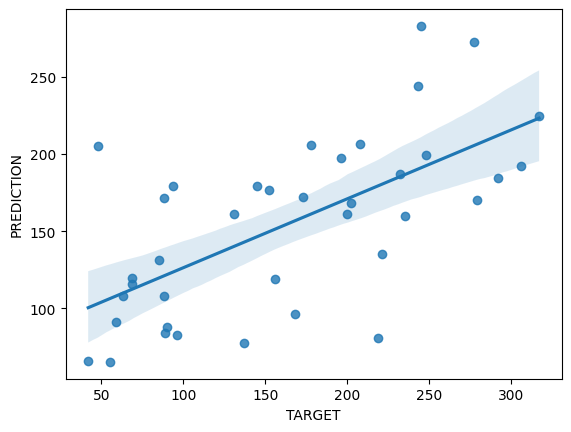

In [17]:
# Plot actual vs predicted 
g = sns.regplot(data=test_result["TARGET", "PREDICTION"].to_pandas().astype("float64"), x="TARGET", y="PREDICTION")

plt.show()

<a id="deploy_udf"></a>
### 2.4 Deploy the simple model as a UDF

In [18]:
# Get the xbgoost object for the UDF
sk_xgboost = regressor.to_xgboost()

# Pickle to a local file
XGB_FILE = 'xgboost.joblib'
joblib.dump(sk_xgboost, XGB_FILE)

# Upload the file to cloud storage
session.file.put(XGB_FILE, "@demo_stage", overwrite=True)

num_features = len(preprocessed_test_df.columns) - 1

In [19]:
# Cache the model load to optimize inference
@cachetools.cached(cache={})
def load_model(filename):
    import joblib
    import sys
    import os

    IMPORT_DIRECTORY_NAME = "snowflake_import_directory"
    import_dir = sys._xoptions[IMPORT_DIRECTORY_NAME]

    if import_dir:
        with open(os.path.join(import_dir, filename), 'rb') as file:
            m = joblib.load(file)
            return m
        
# Register the UDF via decorator
@udf(name='xgboost_udf',
     session=session, 
     replace=True, 
     is_permanent=True, 
     stage_location='@DEMO_STAGE',
     input_types=[F.FloatType()]*num_features,
     return_type=F.FloatType(),
     imports=['@DEMO_STAGE/xgboost.joblib.gz'],
     packages=['numpy','pandas','joblib','cachetools','xgboost'])
def xbboost_udf(input_df: pd.DataFrame) -> pd.Series:
    # Need to name the columns because column names aren't passed in to this function
    input_df.columns = FEATURE_COLUMNS
    model = load_model('xgboost.joblib.gz')
    return model.predict(input_df) # This is using the XGBoost library's model.predict(), not Snowpark ML's

The version of package 'cachetools' in the local environment is 5.5.2, which does not fit the criteria for the requirement 'cachetools'. Your UDF might not work when the package version is different between the server and your local environment.


In [20]:
# To test the XGBoost UDF, write the test data to a table with numbers only
preprocessed_test_df.write.mode('overwrite').save_as_table('diabetes_test_as_numbers')

# Test the UDF using a SQL SELECT statement
(session.
 sql('select target, xgboost_udf(* exclude target) as prediction from diabetes_test_as_numbers limit 5').
 show()
)

---------------------------------
|"TARGET"  |"PREDICTION"        |
---------------------------------
|168       |95.96307373046875   |
|245       |283.1009826660156   |
|137       |77.37944030761719   |
|131       |161.43563842773438  |
|202       |168.35244750976562  |
---------------------------------



### MyNote
Can also use function simply as SQL in snowsight
```sql
use schema rkirk_db.snowflake_ml_py_lesson;

select target, xgboost_udf(* exclude target) as prediction from diabetes_test_as_numbers limit 5;
```

<a id="Gridsearch"></a>
### 2.5 Gridsearch

Now, let's use Snowpark ML's `GridSearchCV()` function to find optimal model parameters!

GridSearchCV performs an exhaustive search over specified parameter values for an estimator. This means that all combinations are tested. 

In GridSearchCV, along with grid search, cross validation is used while training the model. We know that before training the model with data, we divided the data into two parts – train data and test data. In cross validation, the process divides the train data further into parts – partitions used for train data and validation data, to determine a "best fit" set of hyperparameters. By default, GridSearchCV performs 5-fold cross-validation.

### Create a complete ML pipeline

This time, rather than prepare the training features with a preprocessing pipeline and then following that with a model training step, we'll assemble a complete ML pipeline that combines feature transformation and the model in a single object. The resulting object will then be able to perform inferencing on inputs **in the original form used for training.**

In [21]:
# Categorize features for preprocessing

# Numerical columns to undergo MinMax scaling
MINMAX_COLUMNS = ["BLOOD_SERUM1", "BLOOD_SERUM2", "BLOOD_SERUM3", "BLOOD_SERUM4", "BLOOD_SERUM5", "BLOOD_SERUM6"]

# Columns for one-hot encoding
CATEGORICAL_COLUMNS = ["SEX"]

# Columns for ordinal encoding, along with order
ORDINAL_COLUMNS = ["BMI"]
ORDINAL_CATEGORIES = {
    "BMI": np.array(["underweight", "normal", "overweight", "obese", "extremely_obese"])

}

# Define the full ML pipeline, including the grid search.
ml_pipeline = Pipeline(
    steps=[
            (
                "MMS",
                SNOWML.MinMaxScaler(
                    clip=True,
                    input_cols=MINMAX_COLUMNS,
                    output_cols=MINMAX_COLUMNS,    # Replace original columns
                )
            ),
            (
                "OE",
                SNOWML.OrdinalEncoder(
                    input_cols=ORDINAL_COLUMNS,
                    output_cols=ORDINAL_COLUMNS,     # Replace original columns
                    categories=ORDINAL_CATEGORIES,   # Ordinal information
                )
            ),
            (
                "UPPER",
                StringToUpper(
                    input_cols=CATEGORICAL_COLUMNS,
                    output_cols=CATEGORICAL_COLUMNS     # Replace original columns
                )
            ),
            (
                "OHE",
                SNOWML.OneHotEncoder(
                    input_cols=CATEGORICAL_COLUMNS,
                    output_cols=CATEGORICAL_COLUMNS,
                    drop_input_cols=True              # Remove original column
                )
            ),
            (
                "XGBOOST_GRID_SEARCH",
                GridSearchCV(
                    estimator=XGBRegressor(),
                    param_grid={
                        "n_estimators":[50, 100, 200, 300, 400, 500],
                        "learning_rate":[0.05, 0.1, 0.2, 0.3, 0.4, 0.5],
                    },
                    n_jobs = -1,
                    scoring="neg_mean_absolute_percentage_error",
                    label_cols='TARGET',
                    output_cols='PREDICTION'
                )
            )
    ]
)

In preparation for the grid search, use a larger warehouse to gain parallelism

In [ ]:
# Alter warehouse size.
user = snowflake_environment[0][0]

_ = session.sql(f"alter warehouse {user}_wh set warehouse_size = large").collect()

Fit feature transformations and perform grid search

This will likely take around 35-40 seconds.

In [23]:
%time ml_pipeline.fit(diabetes_train_df)  # Use original untransformed training set

Package 'fastparquet' is not installed in the local environment. Your UDF might not work when the package is installed on the server but not on your local environment.
The version of package 'cachetools' in the local environment is 5.5.2, which does not fit the criteria for the requirement 'cachetools<6'. Your UDF might not work when the package version is different between the server and your local environment.


CPU times: user 769 ms, sys: 219 ms, total: 988 ms
Wall time: 1min 11s


In [27]:
# Reset warehouse size
_ = session.sql(f"alter warehouse {user}_wh set warehouse_size = xsmall").collect()

All fitted components of the trained ml pipeline are available.

In [25]:
ml_pipeline.steps

[('MMS',
  <snowflake.ml.modeling.preprocessing.min_max_scaler.MinMaxScaler at 0x13ccebf50>),
 ('OE',
  <snowflake.ml.modeling.preprocessing.ordinal_encoder.OrdinalEncoder at 0x13cce92b0>),
 ('UPPER', <pipeline_string_to_upper.StringToUpper at 0x13ccebec0>),
 ('OHE',
  <snowflake.ml.modeling.preprocessing.one_hot_encoder.OneHotEncoder at 0x13cce9c10>),
 ('XGBOOST_GRID_SEARCH',
  <snowflake.ml.modeling.model_selection.grid_search_cv.GridSearchCV at 0x13cce8d10>)]

In [ ]:
# MyNote: For some reason this hung first time, but after resarting kernel it worked instantly. Second time i did delay resizing the warehouse to small
# until after running this.
# Get the grid search object
grid_search = ml_pipeline.steps[4][1]

We can use `to_sklearn()` in order to get the actual xgboost model object, which gives us access to all its attributes.

In [28]:
grid_search.to_sklearn().best_estimator_

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


The parameters of the tuned model are visible above. They can also be accessed programmatically.

In [ ]:
tuned_model = grid_search.to_sklearn().best_estimator_
n_est = tuned_model.n_estimators
l_rate = tuned_model.learning_rate
print(f"Hyperparameters found by grid search: n_estimators = {n_est} , learning_rate = {l_rate}")

We can also analyze the grid search results.

In [ ]:
# Analyze grid search results
gs_results = grid_search.to_sklearn().cv_results_
n_estimators_val = []
learning_rate_val = []
for param_dict in gs_results["params"]:
    n_estimators_val.append(param_dict["n_estimators"])
    learning_rate_val.append(param_dict["learning_rate"])
mape_val = gs_results["mean_test_score"]*-1

gs_results_df = pd.DataFrame(data={
    "n_estimators":n_estimators_val,
    "learning_rate":learning_rate_val,
    "mape":mape_val})

sns.relplot(data=gs_results_df, x="learning_rate", y="mape", hue="n_estimators", kind="line")

plt.show()

This is consistent with the `learning_rate` and `n_estimator` values chosen as the best estimator with the lowest MAPE.

Now, let's predict and analyze the results using the fitted ML pipeline, which will apply the best model found.

In [ ]:
# Predict
result = ml_pipeline.predict(diabetes_test_df)

# Analyze results
mape_from_test_eval = mean_absolute_percentage_error(df=result, 
                                        y_true_col_names="TARGET", 
                                        y_pred_col_names="PREDICTION")

result.select("TARGET", "PREDICTION").show()
print(f"Mean absolute percentage error: {mape_from_test_eval}")

In [ ]:
# Plot actual vs predicted 
g = sns.regplot(data=result["TARGET", "PREDICTION"].to_pandas().astype("float64"), x="TARGET", y="PREDICTION")
plt.show()

In [ ]:
session.close()